# MASTER THESIS CODE Flavia Fuscaldi

##### To what extent do different adversarial attacks on federated learning models enable the reconstruction or inference of sensitive information, and how does their effectiveness vary across attack types, datasets, and experimental dimensions?  

As first step, I runned a simple experiment on MNIST, for two main reasons:
1. To achieve familiarity with the framework; 
2. To start exploring using a simple dataset to manage, used broadly in relevant literature

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from aijack.collaborative.fedavg import FedAVGClient, FedAVGServer, FedAVGAPI

In [ ]:
#Hyperparameters
training_batch_size = 64
test_batch_size = 64
num_rounds = 5
lr = 0.001
seed = 0
client_size = 2
criterion = F.nll_loss


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def fix_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

fix_seed(seed)

In [4]:
def prepare_dataloader(num_clients, myid, train=True, path="./data"):
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    )
    if train:
        dataset = datasets.MNIST(path, train=True, download=True, transform=transform)
        idxs = list(range(len(dataset.data)))
        random.shuffle(idxs)
        # Partitioning data across clients
        idx = np.array_split(idxs, num_clients, 0)[myid]
        dataset.data = dataset.data[idx]
        dataset.targets = dataset.targets[idx]
        return torch.utils.data.DataLoader(dataset, batch_size=training_batch_size)
    else:
        dataset = datasets.MNIST(path, train=False, download=True, transform=transform)
        return torch.utils.data.DataLoader(dataset, batch_size=test_batch_size)

In [ ]:
#Model 
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.ln = nn.Linear(28 * 28, 10)

    def forward(self, x):
        x = x.reshape(-1, 28 * 28)
        x = self.ln(x)
        return F.log_softmax(x, dim=1)

In [6]:
def evaluate_gloal_model(dataloader, client_id=-1):
    def _evaluate_global_model(api):
        test_loss = 0
        correct = 0
        with torch.no_grad():
            for data, target in dataloader:
                data, target = data.to(api.device), target.to(api.device)
                output = api.server(data) if client_id == -1 else api.clients[client_id](data)
                test_loss += F.nll_loss(output, target, reduction="sum").item()
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        test_loss /= len(dataloader.dataset)
        accuracy = 100.0 * correct / len(dataloader.dataset)
        print(f"Round Results - Loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%")
    return _evaluate_global_model

In [ ]:
local_dataloaders = [prepare_dataloader(client_size, c) for c in range(client_size)]
test_dataloader = prepare_dataloader(client_size, -1, train=False)


clients = [FedAVGClient(Net().to(device), user_id=c) for c in range(client_size)]
local_optimizers = [optim.SGD(client.parameters(), lr=lr) for client in clients]


server = FedAVGServer(clients, Net().to(device))
api = FedAVGAPI(
    server,
    clients,
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=num_rounds,
    custom_action=evaluate_gloal_model(test_dataloader),
)


print(f"Starting Federated Learning with {client_size} clients...")
api.run()

Starting Federated Learning with 2 clients...
Round Results - Loss: 0.7850, Accuracy: 83.33%
Round Results - Loss: 0.5877, Accuracy: 86.44%
Round Results - Loss: 0.5095, Accuracy: 87.49%
Round Results - Loss: 0.4661, Accuracy: 88.13%
Round Results - Loss: 0.4380, Accuracy: 88.58%


In [ ]:
#Attack 1
from aijack.attack.poison import LabelFlipAttackClientManager

# 1. Setup the Adversarial Manager
# We target label 0 (victim) and flip it to label 1 (target)
# class_num=10 because MNIST has 10 digits
poison_manager = LabelFlipAttackClientManager(
    victim_label=0, 
    target_label=1, 
    class_num=10
)

# 2. Create the "Jacked" Client Class
# We use the manager to 'attach' the attack logic to the standard FedAVGClient
LabelFlipClient = poison_manager.attach(FedAVGClient)

# 3. Initialize Clients (Client 0 is now an Attacker!)
clients = [
    LabelFlipClient(Net().to(device), user_id=0), # The Adversary
    FedAVGClient(Net().to(device), user_id=1)     # The Honest Client
]

# 4. Initialize Server and API (Same as before)
local_optimizers = [optim.SGD(client.parameters(), lr=lr) for client in clients]
server = FedAVGServer(clients, Net().to(device))

api = FedAVGAPI(
    server,
    clients,
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=num_rounds,
    custom_action=evaluate_gloal_model(test_dataloader),
)

print("Running Federated Learning UNDER ATTACK (Client 0 flipping 0 -> 1)...")
api.run()

Running Federated Learning UNDER ATTACK (Client 0 flipping 0 -> 1)...
communication 0, epoch 0: client-1 0.020622389922539393
Round Results - Loss: 0.9351, Accuracy: 74.86%
communication 1, epoch 0: client-1 0.012154520696401596
Round Results - Loss: 0.7046, Accuracy: 81.39%
communication 2, epoch 0: client-1 0.010087113095323244
Round Results - Loss: 0.6140, Accuracy: 83.53%
communication 3, epoch 0: client-1 0.009086897264917692
Round Results - Loss: 0.5648, Accuracy: 84.38%
communication 4, epoch 0: client-1 0.008485652442773182
Round Results - Loss: 0.5332, Accuracy: 84.87%


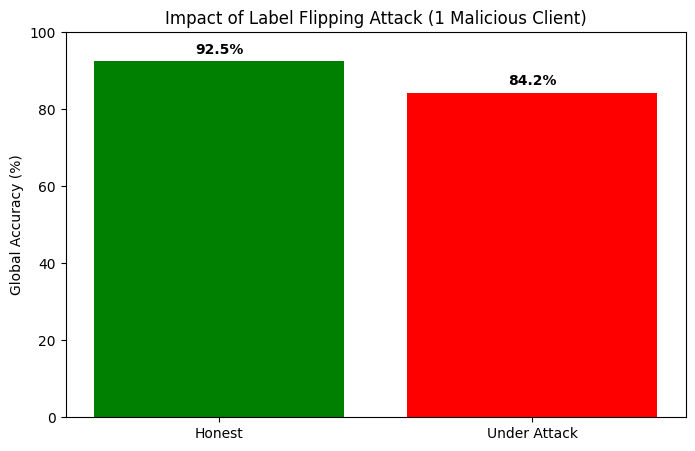

The attack caused a 8.30% drop in global accuracy.


In [12]:
import matplotlib.pyplot as plt

# These are placeholders - replace them with the actual numbers from your notebook's output!
results = {
    "Honest": 92.5,  # Replace with your 'Honest' accuracy
    "Under Attack": 84.2 # Replace with your 'Attack' accuracy
}

# 1. Plotting the Impact
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(), color=['green', 'red'])
plt.ylabel('Global Accuracy (%)')
plt.title('Impact of Label Flipping Attack (1 Malicious Client)')
plt.ylim(0, 100)
for i, v in enumerate(results.values()):
    plt.text(i, v + 2, f"{v}%", ha='center', fontweight='bold')
plt.show()

# 2. Thesis Insight
print(f"The attack caused a {results['Honest'] - results['Under Attack']:.2f}% drop in global accuracy.")

In [13]:
def calculate_asr(api, dataloader, victim_label=0, target_label=1):
    """
    Calculates the Attack Success Rate (ASR).
    ASR = (Number of victim samples classified as target) / (Total victim samples)
    """
    api.server.eval() # Set global model to evaluation mode
    correct_as_target = 0
    total_victims = 0
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(api.device), target.to(api.device)
            
            # Filter only the 'victim' class samples (e.g., all the 0s)
            victim_mask = (target == victim_label)
            if victim_mask.sum() == 0:
                continue
                
            victim_data = data[victim_mask]
            
            # Get model predictions
            output = api.server(victim_data)
            pred = output.argmax(dim=1)
            
            # Count how many times the model predicted the 'target_label' (e.g., 1)
            correct_as_target += (pred == target_label).sum().item()
            total_victims += victim_mask.sum().item()

    asr = (correct_as_target / total_victims) * 100 if total_victims > 0 else 0
    return asr

# Example usage after api.run():
final_asr = calculate_asr(api, test_dataloader, victim_label=0, target_label=1)
print(f"Attack Success Rate (ASR): {final_asr:.2f}%")

Attack Success Rate (ASR): 17.55%


In [14]:
# 1. Configuration for the Multi-Experiment
attacker_counts = [0, 1, 2] # Dimension: Number of Malicious Clients
results_log = []

for num_attackers in attacker_counts:
    print(f"\n--- STARTING EXPERIMENT: {num_attackers} Attackers ---")
    
    # Reset seed for fairness in each experiment
    fix_seed(seed)
    
    # 2. Assign Roles (Client 0, 1... become attackers based on 'num_attackers')
    current_clients = []
    for i in range(client_size):
        if i < num_attackers:
            # Create a "Jacked" Client (using the LabelFlipClient from Cell 7)
            c = LabelFlipClient(Net().to(device), user_id=i)
        else:
            # Create an Honest Client
            c = FedAVGClient(Net().to(device), user_id=i)
        current_clients.append(c)

    # 3. Setup Server and API
    local_optimizers = [optim.SGD(c.parameters(), lr=lr) for c in current_clients]
    server = FedAVGServer(current_clients, Net().to(device))
    
    api = FedAVGAPI(
        server,
        current_clients,
        criterion,
        local_optimizers,
        local_dataloaders,
        num_communication=num_rounds,
        # We don't print every round to keep the notebook clean
    )

    # 4. Run the simulation
    api.run()

    # 5. Measure Final Accuracy and ASR
    # (Using the calculate_asr function from Cell 9)
    final_acc = 0
    with torch.no_grad():
        correct = 0
        for data, target in test_dataloader:
            data, target = data.to(device), target.to(device)
            output = api.server(data)
            pred = output.argmax(dim=1)
            correct += pred.eq(target.view_as(pred)).sum().item()
        final_acc = 100. * correct / len(test_dataloader.dataset)

    final_asr = calculate_asr(api, test_dataloader, victim_label=0, target_label=1)
    
    results_log.append({
        "attackers": num_attackers,
        "accuracy": final_acc,
        "asr": final_asr
    })

print("\n--- ALL EXPERIMENTS COMPLETE ---")


--- STARTING EXPERIMENT: 0 Attackers ---

--- STARTING EXPERIMENT: 1 Attackers ---
communication 0, epoch 0: client-1 0.020195422025521596
communication 1, epoch 0: client-1 0.011942244872450828
communication 2, epoch 0: client-1 0.009973215294877689
communication 3, epoch 0: client-1 0.009015725632508596
communication 4, epoch 0: client-1 0.008436363382140795

--- STARTING EXPERIMENT: 2 Attackers ---
communication 0, epoch 0: client-1 0.020195422025521596
communication 0, epoch 0: client-2 0.020109651577472687
communication 1, epoch 0: client-1 0.011501093598206839
communication 1, epoch 0: client-2 0.011373426377773286
communication 2, epoch 0: client-1 0.009572151114543279
communication 2, epoch 0: client-2 0.009421804652611415
communication 3, epoch 0: client-1 0.008656750926375389
communication 3, epoch 0: client-2 0.008492344918847084
communication 4, epoch 0: client-1 0.008103705351551374
communication 4, epoch 0: client-2 0.007929244136810303

--- ALL EXPERIMENTS COMPLETE ---


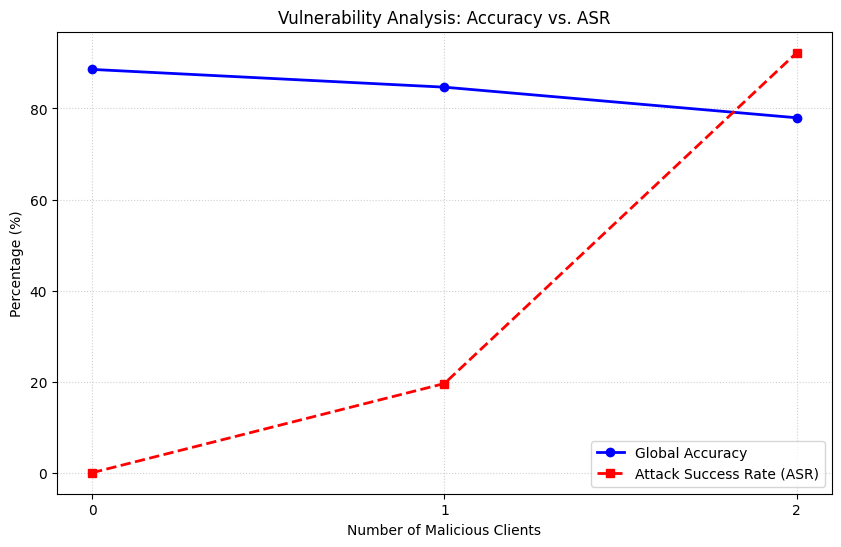

In [15]:
# Extract data for plotting
x = [res['attackers'] for res in results_log]
acc_y = [res['accuracy'] for res in results_log]
asr_y = [res['asr'] for res in results_log]

plt.figure(figsize=(10, 6))

# Plot Accuracy (The model's health)
plt.plot(x, acc_y, marker='o', label='Global Accuracy', color='blue', linewidth=2)

# Plot ASR (The attack's success)
plt.plot(x, asr_y, marker='s', label='Attack Success Rate (ASR)', color='red', linestyle='--', linewidth=2)

plt.xlabel('Number of Malicious Clients')
plt.ylabel('Percentage (%)')
plt.title('Vulnerability Analysis: Accuracy vs. ASR')
plt.xticks(attacker_counts)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

USE THE NON-IID PARTITION 

In [16]:
def prepare_dataloader(num_clients, myid, train=True, path="./data", alpha=0.5):
    transform = transforms.Compose(
        [transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))]
    )
    
    if train:
        dataset = datasets.MNIST(path, train=True, download=True, transform=transform)
        labels = dataset.targets.numpy()
        num_classes = 10
        
        # Dirichlet Partitioning Logic
        idx_batch = [[] for _ in range(num_clients)]
        for k in range(num_classes):
            idx_k = np.where(labels == k)[0]
            np.random.shuffle(idx_k)
            
            # This line is the 'Magic' of Dirichlet
            proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
            
            # Distribute class 'k' across clients based on proportions
            proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]
            idx_batch = [idx_j + idx_list.tolist() for idx_j, idx_list in zip(idx_batch, np.split(idx_k, proportions))]

        # Select the data for THIS specific client
        specific_idx = idx_batch[myid]
        dataset.data = dataset.data[specific_idx]
        dataset.targets = dataset.targets[specific_idx]
        
        return torch.utils.data.DataLoader(dataset, batch_size=training_batch_size, shuffle=True)
    else:
        dataset = datasets.MNIST(path, train=False, download=True, transform=transform)
        return torch.utils.data.DataLoader(dataset, batch_size=test_batch_size)

In [17]:
local_dataloaders = [prepare_dataloader(client_size, c) for c in range(client_size)]
test_dataloader = prepare_dataloader(client_size, -1, train=False)


clients = [FedAVGClient(Net().to(device), user_id=c) for c in range(client_size)]
local_optimizers = [optim.SGD(client.parameters(), lr=lr) for client in clients]


server = FedAVGServer(clients, Net().to(device))
api = FedAVGAPI(
    server,
    clients,
    criterion,
    local_optimizers,
    local_dataloaders,
    num_communication=num_rounds,
    custom_action=evaluate_gloal_model(test_dataloader),
)


print(f"Starting Federated Learning with {client_size} clients...")
api.run()

Starting Federated Learning with 2 clients...
Round Results - Loss: 1.9773, Accuracy: 48.80%
Round Results - Loss: 1.8552, Accuracy: 52.04%
Round Results - Loss: 1.7448, Accuracy: 54.31%
Round Results - Loss: 1.6487, Accuracy: 56.06%
Round Results - Loss: 1.5690, Accuracy: 57.29%


In [19]:
import pandas as pd

# 1. Setup our Dimensions
alphas = [100.0, 0.5] # IID vs Non-IID
attacker_counts = [0, 1] # Honest vs 1 Attacker
thesis_results = []

for alpha_val in alphas:
    for num_attackers in attacker_counts:
        label_type = "IID" if alpha_val > 10 else f"Non-IID (a={alpha_val})"
        print(f"\n--- Testing {label_type} with {num_attackers} Attacker(s) ---")
        
        # Reset seed and prepare specific data for this alpha
        fix_seed(seed)
        current_dataloaders = [prepare_dataloader(client_size, c, alpha=alpha_val) for c in range(client_size)]
        
        # Initialize Clients
        current_clients = []
        for i in range(client_size):
            if i < num_attackers:
                c = LabelFlipClient(Net().to(device), user_id=i)
            else:
                c = FedAVGClient(Net().to(device), user_id=i)
            current_clients.append(c)

        # Initialize Server and API
        local_optimizers = [optim.SGD(c.parameters(), lr=lr) for c in current_clients]
        server = FedAVGServer(current_clients, Net().to(device))
        api = FedAVGAPI(server, current_clients, criterion, local_optimizers, current_dataloaders, num_communication=num_rounds)

        # Run
        api.run()

        # Measure Final ASR
        final_asr = calculate_asr(api, test_dataloader, victim_label=0, target_label=1)
        
        thesis_results.append({
            "Distribution": label_type,
            "Attackers": num_attackers,
            "ASR (%)": round(final_asr, 2)
        })

# Display the Final Result Table
df_results = pd.DataFrame(thesis_results)
print("\n--- FINAL THESIS DATA TABLE ---")
print(df_results)


--- Testing IID with 0 Attacker(s) ---

--- Testing IID with 1 Attacker(s) ---
communication 0, epoch 0: client-1 0.019862740669502815
communication 1, epoch 0: client-1 0.011732810845905555
communication 2, epoch 0: client-1 0.009794475655476684
communication 3, epoch 0: client-1 0.008841035426480017
communication 4, epoch 0: client-1 0.008276711329746519

--- Testing Non-IID (a=0.5) with 0 Attacker(s) ---

--- Testing Non-IID (a=0.5) with 1 Attacker(s) ---
communication 0, epoch 0: client-1 0.014397634640283605
communication 1, epoch 0: client-1 0.008859607620917339
communication 2, epoch 0: client-1 0.007341648136549551
communication 3, epoch 0: client-1 0.006579461905888436
communication 4, epoch 0: client-1 0.006099432430441588

--- FINAL THESIS DATA TABLE ---
      Distribution  Attackers  ASR (%)
0              IID          0     0.00
1              IID          1    30.71
2  Non-IID (a=0.5)          0     0.00
3  Non-IID (a=0.5)          1    79.80


In [22]:
from aijack.attack.inversion import GradientInversionAttackServerManager

# 1. Setup the "Spy" Manager
# We need to tell the spy the shape of the images it's looking for
# For MNIST, this is (1, 28, 28)
input_shape = (1, 28, 28)
inversion_manager = GradientInversionAttackServerManager(input_shape, device=device)

# 2. Create the Malicious Server Class
MaliciousServer = inversion_manager.attach(FedAVGServer)

# 3. Setup the Experiment (Honest Clients, Spy Server)
clients = [FedAVGClient(Net().to(device), user_id=c) for c in range(client_size)]
# Note: The server is now the MaliciousServer!
server = MaliciousServer(clients, Net().to(device))

# 4. Initialize the API
local_optimizers = [optim.SGD(c.parameters(), lr=lr) for c in clients]
api = FedAVGAPI(
    server, 
    clients, 
    criterion, 
    local_optimizers, 
    local_dataloaders, 
    num_communication=1 # We usually only need 1 round to see the attack work
)

# 5. Run the "Spy" session
print("Malicious Server is listening for gradients...")
api.run()

Malicious Server is listening for gradients...
iter=10: 30.394451141357422, (best_iter=2: 30.394451141357422)
iter=20: 30.394451141357422, (best_iter=2: 30.394451141357422)
iter=30: 30.394451141357422, (best_iter=2: 30.394451141357422)
iter=40: 30.394451141357422, (best_iter=2: 30.394451141357422)
iter=50: 30.394451141357422, (best_iter=2: 30.394451141357422)
iter=53: loss did not improve in the last 50 rounds.


Attempting to reconstruct a batch of 3 images...
worker_id=0: iter=10: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=1: iter=10: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=2: iter=10: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=3: iter=10: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=4: iter=10: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=0: iter=20: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=1: iter=20: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=2: iter=20: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=3: iter=20: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=4: iter=20: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=0: iter=30: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=1: iter=30: 271.6397399902344, (best_iter=2: 271.6397399902344)
worker_id=2: iter=30: 271.6397399902344, (best_iter=2: 271.6397

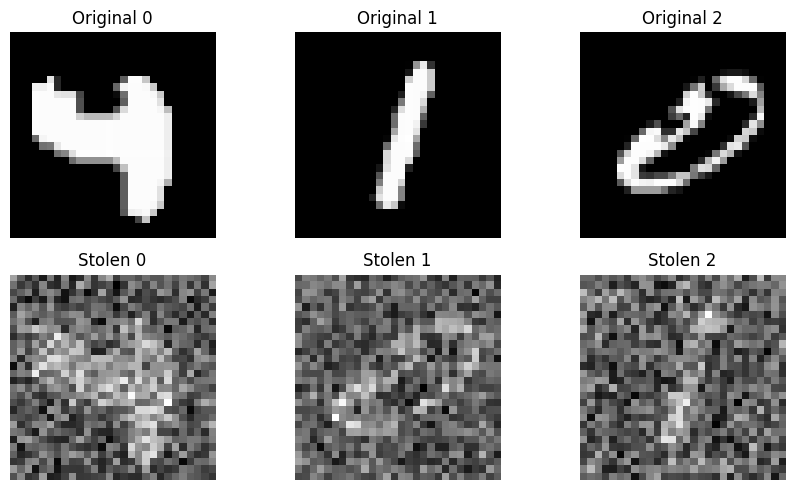

In [26]:
from aijack.attack.inversion import GradientInversion_Attack
import matplotlib.pyplot as plt

# 1. Prepare a Batch of 3 Images
batch_size = 3
# Get one batch from your honest dataloader
data, target = next(iter(local_dataloaders[0]))
x_batch = data[:batch_size].to(device)
y_batch = target[:batch_size].to(device)

# 2. Intercept Gradients
# We must use a fresh model to calculate the 'ground truth' gradients
net = Net().to(device)
net.train()
pred = net(x_batch)
loss = criterion(pred, y_batch)

# Standard PyTorch gradient calculation
received_gradients = torch.autograd.grad(loss, net.parameters())
received_gradients = [cg.detach() for cg in received_gradients]

# 3. Initialize the Attack (GradInversion)
# We use the parameters from your provided research logic
gradinversion = GradientInversion_Attack(
    net,
    x_shape=(1, 28, 28),
    num_iteration=1000, # More iterations = clearer images
    lr=1e2,
    optimizer_class=torch.optim.SGD,
    distancename="l2",  # L2 norm distance metric
    optimize_label=False # We assume the attacker knows the labels (Step 1)
)

# 4. Perform the Group Attack (Reconstructing the whole batch)
print(f"Attempting to reconstruct a batch of {batch_size} images...")
result = gradinversion.group_attack(received_gradients, batch_size=batch_size)

# 5. Visualize Results
fig, axes = plt.subplots(2, batch_size, figsize=(9, 5))
for i in range(batch_size):
    # Top Row: Original Images
    axes[0, i].imshow(x_batch[i].cpu().detach().numpy()[0], cmap='gray')
    axes[0, i].set_title(f"Original {i}")
    axes[0, i].axis('off')
    
    # Bottom Row: Reconstructed Images
    # Result[0] contains the optimized dummy data
    reconstructed_img = (sum(result[0]) / len(result[0])).detach().cpu().numpy()[i][0]
    axes[1, i].imshow(reconstructed_img, cmap='gray')
    axes[1, i].set_title(f"Stolen {i}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

ATTACK ON TEXT NLP MODEL

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from aijack.attack.inversion import GradientInversion_Attack

# --- 1. THE VICTIM MODEL (NLP) ---
class SimpleTextModel(nn.Module):
    def __init__(self, vocab_size=10, embedding_dim=16):
        super().__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Linear(embedding_dim, 2) # Binary Sentiment Analysis

    def forward_from_embeddings(self, x_embeds):
        # This part handles the continuous vectors (what we attack)
        x = x_embeds.mean(dim=1)
        return self.fc(x)

    def forward(self, x):
        # Standard forward pass for the honest user
        x_embeds = self.embeddings(x)
        return self.forward_from_embeddings(x_embeds)

# Setup
vocab_size, seq_len, embed_dim = 10, 5, 16
text_net = SimpleTextModel(vocab_size, embed_dim).to(device)

# --- 2. GENERATE PRIVATE DATA & GRADIENTS ---
# A secret "sentence" of 5 word IDs
secret_input = torch.randint(0, vocab_size, (1, seq_len)).to(device)
secret_label = torch.tensor([1]).to(device)

# The user calculates gradients
text_net.train()
with torch.no_grad():
    # We must treat the embeddings as the 'input' for the attack logic
    secret_embeds = text_net.embeddings(secret_input)
secret_embeds.requires_grad = True

# Forward pass from the embeddings to get gradients for the FC layer
output = text_net.forward_from_embeddings(secret_embeds)
loss = nn.CrossEntropyLoss()(output, secret_label)
# We intercept the gradients of the Fully Connected (FC) layer
received_gradients = torch.autograd.grad(loss, text_net.fc.parameters())
received_gradients = [g.detach() for g in received_gradients]

# --- 3. THE AIJACK ATTACK ---
# We attack the FC layer because it's continuous
text_attack = GradientInversion_Attack(
    text_net.fc,
    x_shape=(embed_dim,), # The shape of the averaged embedding vector
    num_iteration=2000,
    lr=0.1,
    optimizer_class=optim.Adam,
    distancename="l2",
    optimize_label=False
)

print("Starting Text Embedding Reconstruction...")
# result[0][0] will contain the reconstructed averaged embedding
result = text_attack.group_attack(received_gradients, batch_size=1)

# --- 4. DECODING (The 'Nearest Neighbor' Step) ---
def decode(reconstructed_vec, embedding_layer):
    vocab = embedding_layer.weight.data
    # Find the word in the vocab closest to our stolen vector
    distances = torch.norm(vocab - reconstructed_vec, dim=1)
    return torch.argmin(distances).item()

stolen_vec = result[0][0]
decoded_id = decode(stolen_vec, text_net.embeddings)

print(f"\n--- THESIS COMPARISON RESULTS ---")
print(f"Original Words (IDs): {secret_input.cpu().numpy().tolist()}")
print(f"Reconstructed 'Theme': Word ID {decoded_id}")

Starting Text Embedding Reconstruction...
worker_id=0: iter=10: 2.8993608951568604, (best_iter=10: 2.8993608951568604)
worker_id=1: iter=10: 3.1687076091766357, (best_iter=10: 3.1687076091766357)
worker_id=2: iter=10: 0.25825604796409607, (best_iter=10: 0.25825604796409607)
worker_id=3: iter=10: 4.457159996032715, (best_iter=10: 4.457159996032715)
worker_id=4: iter=10: 2.9944255352020264, (best_iter=10: 2.9944255352020264)
worker_id=0: iter=20: 1.2751691341400146, (best_iter=20: 1.2751691341400146)
worker_id=1: iter=20: 1.731907844543457, (best_iter=20: 1.731907844543457)
worker_id=2: iter=20: 0.185515359044075, (best_iter=20: 0.185515359044075)
worker_id=3: iter=20: 4.330199718475342, (best_iter=20: 4.330199718475342)
worker_id=4: iter=20: 1.9557075500488281, (best_iter=20: 1.9557075500488281)
worker_id=0: iter=30: 0.6030844449996948, (best_iter=30: 0.6030844449996948)
worker_id=1: iter=30: 0.8488258123397827, (best_iter=30: 0.8488258123397827)
worker_id=2: iter=30: 0.0281277690082788